In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='husl')

# load cleaned data from Day 1
df = pd.read_csv(
    r'C:\Users\Ashut\Retailpulse\data\processed\retail_clean.csv'
)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"✓ df loaded: {df.shape}")
print(f"Date range: {df['InvoiceDate'].min().date()} → "
      f"{df['InvoiceDate'].max().date()}")
print(f"Columns: {df.columns.tolist()}")

✓ df loaded: (805549, 9)
Date range: 2009-12-01 → 2011-12-09
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'TotalPrice']


In [2]:
mid_date = df['InvoiceDate'].min() + \
    (df['InvoiceDate'].max() - df['InvoiceDate'].min()) / 2

print(f"Full date range: {df['InvoiceDate'].min().date()} "
      f"→ {df['InvoiceDate'].max().date()}")
print(f"Split date:      {mid_date.date()}")
print(f"Training period: {df['InvoiceDate'].min().date()} "
      f"→ {mid_date.date()}")
print(f"Observe period:  {mid_date.date()} "
      f"→ {df['InvoiceDate'].max().date()}")

first_half = df[df['InvoiceDate'] <= mid_date].copy()
second_half = df[df['InvoiceDate'] > mid_date].copy()

print(f"\nFirst half transactions:  {len(first_half):,}")
print(f"Second half transactions: {len(second_half):,}")

# customers in each half
first_customers  = set(first_half['Customer ID'].unique())
second_customers = set(second_half['Customer ID'].unique())

churned_customers = first_customers - second_customers
active_customers  = first_customers & second_customers

print(f"\nCustomers in first half:  {len(first_customers):,}")
print(f"Customers in second half: {len(second_customers):,}")
print(f"Churned (didn't return):  {len(churned_customers):,}")
print(f"Active (came back):       {len(active_customers):,}")
print(f"Churn rate: "
      f"{len(churned_customers)/len(first_customers):.1%}")

Full date range: 2009-12-01 → 2011-12-09
Split date:      2010-12-05
Training period: 2009-12-01 → 2010-12-05
Observe period:  2010-12-05 → 2011-12-09

First half transactions:  403,286
Second half transactions: 402,263

Customers in first half:  4,291
Customers in second half: 4,297
Churned (didn't return):  1,581
Active (came back):       2,710
Churn rate: 36.8%


In [3]:
# calculate RFM from FIRST HALF only
snapshot = mid_date + pd.Timedelta(days=1)

rfm = first_half.groupby('Customer ID').agg(
    recency   = ('InvoiceDate',
                 lambda x: (snapshot - x.max()).days),
    frequency = ('Invoice', 'nunique'),
    monetary  = ('TotalPrice', 'sum')
).reset_index()

rfm['avg_order_value'] = rfm['monetary'] / rfm['frequency']
rfm['is_high_value']   = (
    rfm['monetary'] > rfm['monetary'].quantile(0.75)
).astype(int)

print(f"RFM shape: {rfm.shape}")
print(f"\nRFM sample:")
print(rfm.head())
print(f"\nRFM stats:")
print(rfm.describe().round(2))

RFM shape: (4291, 6)

RFM sample:
   Customer ID  recency  frequency  monetary  avg_order_value  is_high_value
0        12346      160         11    372.86            33.90              0
1        12347       35          1    611.53           611.53              0
2        12348       69          1    222.16           222.16              0
3        12349       39          3   2671.14           890.38              1
4        12351        6          1    300.93           300.93              0

RFM stats:
       Customer ID  recency  frequency  monetary  avg_order_value  \
count      4291.00  4291.00    4291.00   4291.00          4291.00   
mean      15348.94    89.67       4.37   2040.77           385.09   
std        1699.18    95.63       8.00   8722.97           506.93   
min       12346.00     1.00       1.00      2.95             2.95   
25%       13886.00    18.00       1.00    309.12           184.29   
50%       15350.00    51.00       2.00    712.62           291.82   
75%      

RFM with churn: (4291, 7)
Churn rate: 36.8%
Churned:  1,581
Active:   2,710

=== Churn verification ===
recency         correlation: 0.362
frequency       correlation: -0.209
monetary        correlation: -0.108


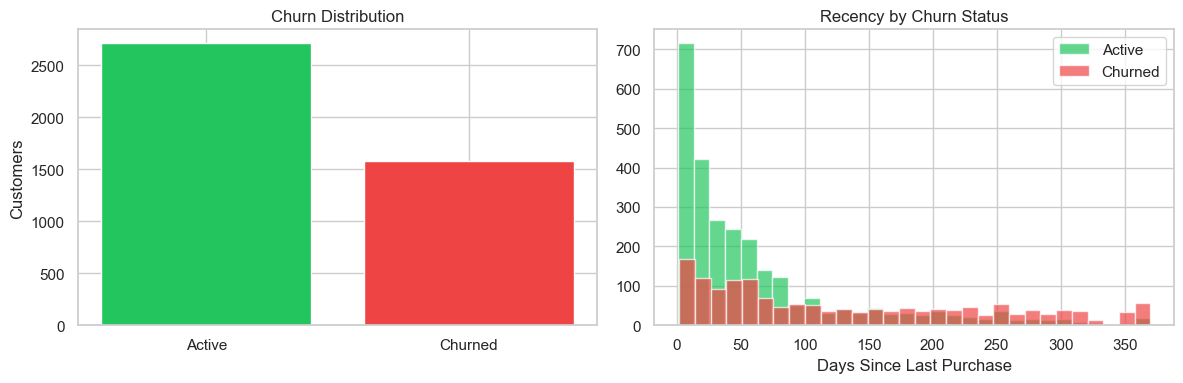

In [4]:
churn_labels = pd.DataFrame({
    'Customer ID': list(first_customers),
    'churned': [
        1 if cid in churned_customers else 0
        for cid in first_customers
    ]
})

# merge into RFM
rfm = rfm.merge(churn_labels, on='Customer ID', how='inner')

print(f"RFM with churn: {rfm.shape}")
print(f"Churn rate: {rfm['churned'].mean():.1%}")
print(f"Churned:  {rfm['churned'].sum():,}")
print(f"Active:   {(rfm['churned']==0).sum():,}")

# verify no perfect split
print(f"\n=== Churn verification ===")
for col in ['recency','frequency','monetary']:
    corr = rfm[col].corr(rfm['churned'])
    print(f"{col:15s} correlation: {corr:.3f}")

# visualise churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Active','Churned'],
            [rfm['churned'].value_counts()[0],
             rfm['churned'].value_counts()[1]],
            color=['#22C55E','#EF4444'])
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Customers')

rfm[rfm['churned']==0]['recency'].hist(
    bins=30, ax=axes[1], alpha=0.7,
    color='#22C55E', label='Active'
)
rfm[rfm['churned']==1]['recency'].hist(
    bins=30, ax=axes[1], alpha=0.7,
    color='#EF4444', label='Churned'
)
axes[1].set_title('Recency by Churn Status')
axes[1].set_xlabel('Days Since Last Purchase')
axes[1].legend()
plt.tight_layout()
plt.savefig('../reports/03_churn_distribution.png', dpi=150)
plt.show()

In [5]:
daily = first_half.groupby(
    ['Customer ID',
     first_half['InvoiceDate'].dt.date]
)['TotalPrice'].sum().reset_index()
daily.columns = ['Customer ID','date','daily_spend']
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values(['Customer ID','date'])

daily['rolling_7d'] = daily.groupby('Customer ID')\
    ['daily_spend'].transform(
        lambda x: x.rolling(7, min_periods=1).mean()
    )
daily['rolling_30d'] = daily.groupby('Customer ID')\
    ['daily_spend'].transform(
        lambda x: x.rolling(30, min_periods=1).mean()
    )

last_rolling = daily.groupby('Customer ID').last()\
    .reset_index()[['Customer ID','rolling_7d','rolling_30d']]
rfm = rfm.merge(last_rolling, on='Customer ID', how='left')
rfm[['rolling_7d','rolling_30d']] = \
    rfm[['rolling_7d','rolling_30d']].fillna(0)

# additional behavioural features
invoice_count = first_half.groupby('Customer ID')\
    ['Invoice'].nunique().reset_index()
invoice_count.columns = ['Customer ID','inv_count']

extra = first_half.groupby('Customer ID').agg(
    first_purchase  = ('InvoiceDate','min'),
    last_purchase   = ('InvoiceDate','max'),
    total_days      = ('InvoiceDate',
                       lambda x: (x.max()-x.min()).days),
    unique_months   = ('InvoiceDate',
                       lambda x: x.dt.month.nunique()),
    unique_products = ('StockCode','nunique'),
    avg_basket_size = ('Quantity','mean'),
    total_quantity  = ('Quantity','sum')
).reset_index()

extra = extra.merge(invoice_count,
                    on='Customer ID', how='left')
extra['purchase_rate'] = (
    extra['inv_count'] / (extra['total_days'] + 1)
)
extra['days_as_customer'] = (
    snapshot - extra['first_purchase']
).dt.days

rfm = rfm.merge(
    extra[['Customer ID','total_days','unique_months',
           'unique_products','avg_basket_size',
           'purchase_rate','days_as_customer']],
    on='Customer ID', how='left'
)
rfm = rfm.fillna(0)

print(f"✓ RFM with all features: {rfm.shape}")
print(f"Columns: {rfm.columns.tolist()}")

✓ RFM with all features: (4291, 15)
Columns: ['Customer ID', 'recency', 'frequency', 'monetary', 'avg_order_value', 'is_high_value', 'churned', 'rolling_7d', 'rolling_30d', 'total_days', 'unique_months', 'unique_products', 'avg_basket_size', 'purchase_rate', 'days_as_customer']


In [6]:
ml_features = [
    'recency','frequency','monetary',
    'avg_order_value','is_high_value',
    'rolling_7d','rolling_30d',
    'total_days','unique_months',
    'unique_products','avg_basket_size',
    'purchase_rate','days_as_customer'
]

print("=== Feature correlations with churn ===")
for feat in ml_features:
    corr = rfm[feat].corr(rfm['churned'])
    bar = '█' * int(abs(corr) * 20)
    direction = '+' if corr > 0 else '-'
    print(f"{feat:20s} {direction}{bar} {corr:.3f}")

# single feature AUC check
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_all = rfm[ml_features]
y_all = rfm['churned']
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2,
    random_state=42, stratify=y_all
)

print("\n=== Single feature AUC ===")
print("(checking for data leakage — no 1.0 allowed)")
leak_found = False
for col in ml_features:
    dt = DecisionTreeClassifier(max_depth=1, random_state=42)
    dt.fit(X_tr[[col]], y_tr)
    auc = roc_auc_score(
        y_te, dt.predict_proba(X_te[[col]])[:,1]
    )
    flag = ' ← ⚠️ LEAKAGE!' if auc >= 0.99 else ''
    if auc >= 0.99:
        leak_found = True
    print(f"{col:20s} AUC: {auc:.4f}{flag}")

if leak_found:
    print("\n❌ Leakage detected — fix before saving!")
else:
    print("\n✓ No leakage — safe to proceed!")

=== Feature correlations with churn ===
recency              +███████ 0.362
frequency            -████ -0.209
monetary             -██ -0.108
avg_order_value      -█ -0.056
is_high_value        -██████ -0.311
rolling_7d           -█ -0.056
rolling_30d          -█ -0.052
total_days           -████████ -0.400
unique_months        -███████ -0.380
unique_products      -█████ -0.261
avg_basket_size      + 0.006
purchase_rate        +███████ 0.357
days_as_customer     -██ -0.150

=== Single feature AUC ===
(checking for data leakage — no 1.0 allowed)
recency              AUC: 0.6800
frequency            AUC: 0.7200
monetary             AUC: 0.7083
avg_order_value      AUC: 0.5923
is_high_value        AUC: 0.6650
rolling_7d           AUC: 0.6083
rolling_30d          AUC: 0.5982
total_days           AUC: 0.7111
unique_months        AUC: 0.7080
unique_products      AUC: 0.6842
avg_basket_size      AUC: 0.5156
purchase_rate        AUC: 0.7111
days_as_customer     AUC: 0.5783

✓ No leakage — safe

In [7]:
import os

ml_features = [
    'recency','frequency','monetary',
    'avg_order_value','is_high_value',
    'rolling_7d','rolling_30d',
    'total_days','unique_months',
    'unique_products','avg_basket_size',
    'purchase_rate','days_as_customer'
]

X = rfm[ml_features]
y = rfm['churned']

print("=== Final ML Dataset ===")
print(f"X shape:     {X.shape}")
print(f"y shape:     {y.shape}")
print(f"Features:    {ml_features}")
print(f"Churn rate:  {y.mean():.1%}")
print(f"Active:      {(y==0).sum():,}")
print(f"Churned:     {(y==1).sum():,}")

# quick cross-validation check
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

model_check = XGBClassifier(
    n_estimators=100, max_depth=3,
    learning_rate=0.1, random_state=42,
    verbosity=0
)
scores = cross_val_score(
    model_check, X, y, cv=5, scoring='roc_auc'
)
print(f"\n=== Pre-save CV check ===")
print(f"AUC scores: {scores.round(4)}")
print(f"Mean AUC:   {scores.mean():.4f}")
print("✓ Ready to save!" if scores.mean() < 0.99
      else "⚠️  Still showing leakage — check features")

# save all files
os.makedirs(
    r'C:\Users\Ashut\Retailpulse\data\processed',
    exist_ok=True
)
X.to_csv(
    r'C:\Users\Ashut\Retailpulse\data\processed\X_churn.csv',
    index=False
)
y.to_csv(
    r'C:\Users\Ashut\Retailpulse\data\processed\y_churn.csv',
    index=False
)
rfm.to_csv(
    r'C:\Users\Ashut\Retailpulse\data\processed\rfm_features.csv',
    index=False
)
rfm.to_csv(
    r'C:\Users\Ashut\Retailpulse\data\processed\rfm_segments.csv',
    index=False
)

print(f"\n✓ Saved X_churn.csv     — {X.shape}")
print(f"✓ Saved y_churn.csv     — {y.shape}")
print(f"✓ Saved rfm_features.csv — {rfm.shape}")
print(f"✓ Saved rfm_segments.csv — {rfm.shape}")

=== Final ML Dataset ===
X shape:     (4291, 13)
y shape:     (4291,)
Features:    ['recency', 'frequency', 'monetary', 'avg_order_value', 'is_high_value', 'rolling_7d', 'rolling_30d', 'total_days', 'unique_months', 'unique_products', 'avg_basket_size', 'purchase_rate', 'days_as_customer']
Churn rate:  36.8%
Active:      2,710
Churned:     1,581

=== Pre-save CV check ===
AUC scores: [0.7668 0.7756 0.7983 0.7797 0.7712]
Mean AUC:   0.7783
✓ Ready to save!

✓ Saved X_churn.csv     — (4291, 13)
✓ Saved y_churn.csv     — (4291,)
✓ Saved rfm_features.csv — (4291, 15)
✓ Saved rfm_segments.csv — (4291, 15)


In [8]:
print("=" * 50)
print("DAY 2 COMPLETE — SUMMARY")
print("=" * 50)
print(f"\nDataset: {df.shape[0]:,} transactions")
print(f"Customers analysed: {len(rfm):,}")
print(f"Churn rate: {rfm['churned'].mean():.1%}")
print(f"Features created: {len(ml_features)}")
print(f"\nChurn definition:")
print(f"  Customers who bought in first half")
print(f"  ({df['InvoiceDate'].min().date()} → "
      f"{mid_date.date()})")
print(f"  but did NOT return in second half")
print(f"  ({mid_date.date()} → "
      f"{df['InvoiceDate'].max().date()})")
print(f"\nFiles saved:")
print(f"  ✓ X_churn.csv      ({X.shape[0]} rows, "
      f"{X.shape[1]} features)")
print(f"  ✓ y_churn.csv      ({y.shape[0]} labels)")
print(f"  ✓ rfm_features.csv ({rfm.shape[0]} customers)")
print(f"  ✓ rfm_segments.csv ({rfm.shape[0]} customers)")
print(f"\nNext: Day 3 — K-Means Segmentation")
print("=" * 50)

DAY 2 COMPLETE — SUMMARY

Dataset: 805,549 transactions
Customers analysed: 4,291
Churn rate: 36.8%
Features created: 13

Churn definition:
  Customers who bought in first half
  (2009-12-01 → 2010-12-05)
  but did NOT return in second half
  (2010-12-05 → 2011-12-09)

Files saved:
  ✓ X_churn.csv      (4291 rows, 13 features)
  ✓ y_churn.csv      (4291 labels)
  ✓ rfm_features.csv (4291 customers)
  ✓ rfm_segments.csv (4291 customers)

Next: Day 3 — K-Means Segmentation
